In [6]:
# Import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import requests
import scipy.stats as stats

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM, logging

logging.set_verbosity_error()

In [7]:
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neo-125m')
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

# load in GPTneo
model = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m')
model.eval()

embed_dim = model.config.hidden_size

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

# Get nouns and verbs

In [8]:
# lists of verbs
url = 'https://raw.githubusercontent.com/david47k/top-english-wordlists/refs/heads/master/top_english_verbs_lower_10000.txt'
verbs = requests.get(url).text
verbs = verbs.split('\n')[:100]

# list of nouns
url = 'https://raw.githubusercontent.com/david47k/top-english-wordlists/refs/heads/master/top_english_nouns_lower_10000.txt'
nouns = requests.get(url).text
nouns = nouns.split('\n')[:100]

# Implant a hook

In [9]:
num_mlp_neurons = model.transformer.h[8].mlp.c_fc.weight.shape[0]

In [10]:
# Hook function to grab the activations
activations = {}

def implant_hook(layer_number):
  def hook(module, input, output):

    # Get the activation
    # acts = module.c_fc(input[0]) # input shape -> (batch, seq_length, 4*embed_dim)
    activations[f'mlp_{layer_number}_c_fc'] = output.detach()
  return hook

In [11]:
layer2hook = 8
hook_name = f'mlp_{layer2hook}_c_fc'

hook_handle = model.transformer.h[layer2hook].mlp.c_fc.register_forward_hook(implant_hook(layer2hook))

In [12]:
# Alternate code for the function using lambda
activations = {}
layer2hook = 8
hook_name = f"mlp_{layer2hook}_c_fc"

hook_handle = model.transformer.h[layer2hook].mlp.c_fc.register_forward_hook(
    lambda m, inp, out: activations.__setitem__(hook_name, out.detach())
)


In [13]:
# test the hook function
# text = 'Are you not entertained?'
text = 'Python'
tokens = tokenizer.encode(text,return_tensors='pt')

# forward pass to trigger the hook
with torch.no_grad(): model(tokens)
activations[hook_name].shape

torch.Size([1, 1, 3072])

In [14]:
# Get activiations for all words
all_activation = np.zeros((2, len(verbs), num_mlp_neurons))

for i, word in enumerate(verbs):
  tokens = tokenizer.encode(word, return_tensors='pt')
  with torch.no_grad(): model(tokens)

  all_activation[0,i,:] = activations[hook_name].mean(dim=1).squeeze().numpy()

for i, word in enumerate(nouns):
  tokens = tokenizer.encode(word, return_tensors='pt')
  with torch.no_grad(): model(tokens)

  all_activation[1,i,:] = activations[hook_name].mean(dim=1).squeeze().numpy()


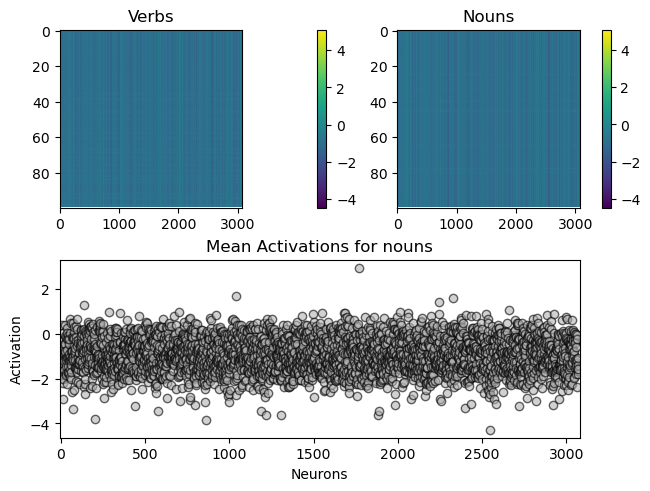

In [15]:
fig = plt.figure(layout="constrained")
axd = fig.subplot_mosaic(
    """
    AB
    CC
    """
)

im0 = axd["A"].imshow(all_activation[0], cmap='viridis', aspect='auto')
axd["A"].set_title("Verbs")
fig.colorbar(im0, ax=axd["A"])

im1 = axd["B"].imshow(all_activation[1], cmap='viridis', aspect='auto')
axd["B"].set_title("Nouns")
fig.colorbar(im1, ax=axd["B"])

axd["C"].plot(all_activation[1].mean(axis=0), 'ko', markerfacecolor=[.7,.7,.7,.6])
axd["C"].set_xlabel("Neurons")
axd["C"].set_ylabel("Activation")
axd["C"].set_title("Mean Activations for nouns")
axd["C"].set_xlim(-6,num_mlp_neurons+7)

plt.show()

# Compare activations with t-test

In [16]:
# Calculate the t and p-test values of the nouns and the verbs
t, p = stats.ttest_1samp(np.diff(all_activation,axis=0), popmean=0, axis=1)

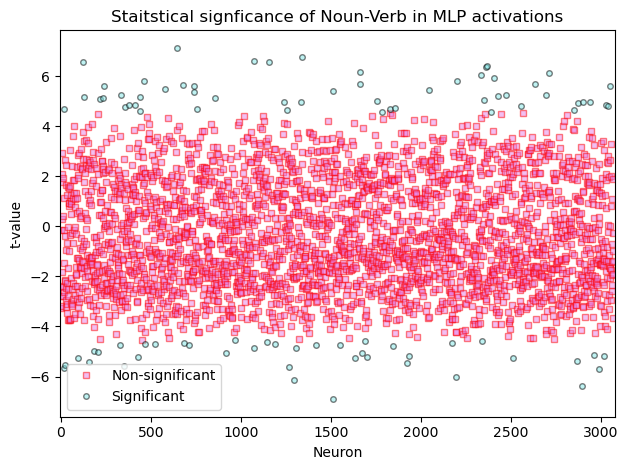

In [17]:
# Visualize

p_thresh = .05/num_mlp_neurons

fig = plt.figure(layout="tight")
plt.plot(np.where(p>p_thresh)[1], t[p>p_thresh], 'rs', markersize=4, markerfacecolor=[.9,.5,.9, .5], label="Non-significant")
plt.plot(np.where(p<p_thresh)[1], t[p<p_thresh], 'ko', markersize=4, markerfacecolor=[.5,.9,.9,.5], label="Significant")

plt.gca().set(xlabel="Neuron", ylabel="t-value", xlim=[-7,num_mlp_neurons+8], title="Staitstical signficance of Noun-Verb in MLP activations")

plt.legend()
plt.show();

In [18]:
# Get the most signifcant and least significant differences
max_t = np.argmin(t) # Index of neuron with the most negative t-value
min_t = np.argmax(t) # Index of neuron with the most positive t-value

print(f"Neuron with most negative t-value: {max_t}")
print(f"Neuron with most positive t-value: {min_t}")

Neuron with most negative t-value: 1512
Neuron with most positive t-value: 642


# Test generalizability using a heatmap in new text

In [19]:
# https://en.wikipedia.org/wiki/Randomness
text = "In common usage, randomness is the apparent or actual lack of definite pattern or predictability in information.[1][2] A random sequence of events, symbols or steps often has no order and does not follow an intelligible pattern or combination. Individual random events are, by definition, unpredictable, but if there is a known probability distribution, the frequency of different outcomes over repeated events (or 'trials') is predictable. For example, when throwing two dice, the outcome of any particular roll is unpredictable, but a sum of 7 will tend to occur twice as often as 4. In this view, randomness is not haphazardness; it is a measure of uncertainty of an outcome. Randomness applies to concepts of chance, probability, and information entropy."
tokens = tokenizer.encode(text,return_tensors='pt')

# get activations from forward pass
with torch.no_grad(): model(tokens)

In [20]:
# min-max scale the activations

activationMax = activations[hook_name][0,:,max_t]
activationMin = activations[hook_name][0,:,min_t]

activationMax = (activationMax-activationMax.min()) / (activationMax.max()-activationMax.min())
activationMin = (activationMin-activationMin.min()) / (activationMin.max()-activationMin.min())

In [21]:
# calculate letter width
fig,ax = plt.subplots(figsize=(10,2))

# draw a text object and get its bounding box
temp_text = ax.text(0,0,'n',fontsize=12,fontfamily='monospace')
bbox = temp_text.get_window_extent(renderer=fig.canvas.get_renderer())

# convert to axis coordinates
inv = ax.transAxes.inverted()
bbox_axes = inv.transform([[bbox.x0,bbox.y0], [bbox.x1,bbox.y1]])
en_width = bbox_axes[1,0] - bbox_axes[0,0] # bbox is [(x0,y0),(x1,y1)]
plt.close(fig) # close the figure

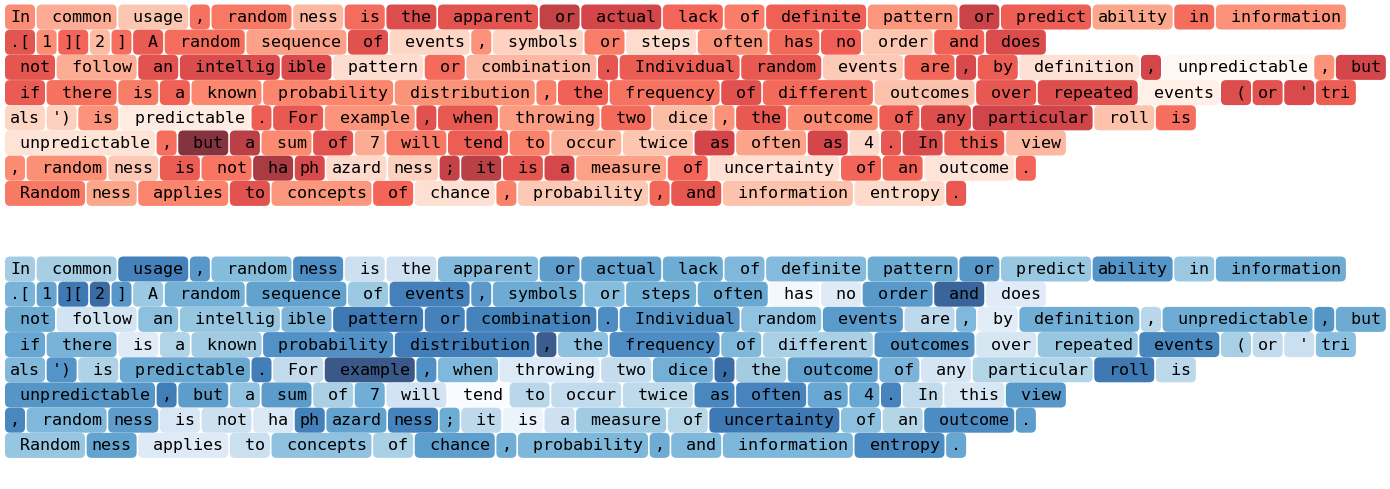

In [22]:
# counter to reset position values
tokenCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

# setup the figure
fig, axs = plt.subplots(2,1,figsize=(10,6))
axs[0].axis('off')
axs[1].axis('off')

for toki in range(len(tokens[0])):

  # decode the token
  word = tokenizer.decode(tokens[0,toki])

  # width of the word
  word_width = en_width*len(word)

  # text object with background color matching the activation
  axs[0].text(x_pos+word_width/2, y_pos, word, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(activationMax[toki]), edgecolor='none', alpha=.8))

  axs[1].text(x_pos+word_width/2, y_pos, word, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Blues(activationMin[toki]), edgecolor='none', alpha=.8))


  # update the word counter and x_pos
  tokenCount += 1
  x_pos += word_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokenCount>=20:
    y_pos -= .12
    x_pos = 0
    tokenCount = 0


plt.show()